In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, Flatten
from tensorflow.keras.layers import Dense, Concatenate

In [2]:
# load the dataset
df = pd.read_csv("Admission_Prediction.csv")

print(df.head())
print(df.shape)

   Serial No.  GRE Score  TOEFL Score  University Rating  SOP  LOR  CGPA  \
0           1        337          118                  4  4.5  4.5  9.65   
1           2        324          107                  4  4.0  4.5  8.87   
2           3        316          104                  3  3.0  3.5  8.00   
3           4        322          110                  3  3.5  2.5  8.67   
4           5        314          103                  2  2.0  3.0  8.21   

   Research  Chance of Admit  Year  \
0         1             0.92  2022   
1         1             0.76  2022   
2         1             0.72  2022   
3         1             0.80  2022   
4         0             0.65  2022   

                              University_Name region  
0    Indian Institute of Technology Kharagpur   East  
1  National Institute of Technology Karnataka  South  
2                          Gujarat University   West  
3                        Jamia Millia Islamia  North  
4                        Jamia Millia I

In [3]:
# remove serial number
df = df.drop("Serial No.", axis=1)

print(df.head())

   GRE Score  TOEFL Score  University Rating  SOP  LOR  CGPA  Research  \
0        337          118                  4  4.5  4.5  9.65         1   
1        324          107                  4  4.0  4.5  8.87         1   
2        316          104                  3  3.0  3.5  8.00         1   
3        322          110                  3  3.5  2.5  8.67         1   
4        314          103                  2  2.0  3.0  8.21         0   

   Chance of Admit  Year                             University_Name region  
0             0.92  2022    Indian Institute of Technology Kharagpur   East  
1             0.76  2022  National Institute of Technology Karnataka  South  
2             0.72  2022                          Gujarat University   West  
3             0.80  2022                        Jamia Millia Islamia  North  
4             0.65  2022                        Jamia Millia Islamia  North  


In [4]:
# convert university names into numbers
uni = df["University_Name"].astype("category")
df["uni_id"] = uni.cat.codes

print(df[["University_Name", "uni_id"]].head())

                              University_Name  uni_id
0    Indian Institute of Technology Kharagpur      18
1  National Institute of Technology Karnataka      27
2                          Gujarat University       9
3                        Jamia Millia Islamia      22
4                        Jamia Millia Islamia      22


In [5]:
# convert region into numbers
reg = df["region"].astype("category")
df["reg_id"] = reg.cat.codes

print(df[["region", "reg_id"]].head())

  region  reg_id
0   East       1
1  South       4
2   West       5
3  North       2
4  North       2


In [6]:
# select numerical features
x_num = df[
    ["GRE Score", "TOEFL Score", "University Rating",
     "SOP", "LOR", "CGPA", "Research", "Year"]
]

y = df["Chance of Admit"]

print(x_num.head())
print(y.head())

   GRE Score  TOEFL Score  University Rating  SOP  LOR  CGPA  Research  Year
0        337          118                  4  4.5  4.5  9.65         1  2022
1        324          107                  4  4.0  4.5  8.87         1  2022
2        316          104                  3  3.0  3.5  8.00         1  2022
3        322          110                  3  3.5  2.5  8.67         1  2022
4        314          103                  2  2.0  3.0  8.21         0  2022
0    0.92
1    0.76
2    0.72
3    0.80
4    0.65
Name: Chance of Admit, dtype: float64


In [7]:
# scale numerical values
sc = StandardScaler()

x_num = sc.fit_transform(x_num)
print(x_num[:5])

[[ 1.56872907  1.49873029  0.74785027  1.07765582  1.2264736   1.73275595
   0.99401789 -1.41421356]
 [ 0.59922691  0.05713942  0.74785027  0.59068979  1.2264736   0.45796167
   0.99401789 -1.41421356]
 [ 0.0026102  -0.33602173 -0.01138858 -0.38324226  0.10466476 -0.96392425
   0.99401789 -1.41421356]
 [ 0.45007273  0.45030057 -0.01138858  0.10372376 -1.01714407  0.13109135
   0.99401789 -1.41421356]
 [-0.14654398 -0.46707544 -0.77062743 -1.35717431 -0.45623965 -0.62071041
  -1.00601811 -1.41421356]]


In [8]:
# split the data
x_train, x_test, y_train, y_test, u_train, u_test, r_train, r_test = train_test_split(
    x_num,
    y,
    df["uni_id"],
    df["reg_id"],
    test_size=0.2,
    random_state=42
)

print("training data:", x_train.shape)
print("testing data:", x_test.shape)

training data: (800, 8)
testing data: (200, 8)


In [9]:
# count categories
n_uni = df["uni_id"].nunique()
n_reg = df["reg_id"].nunique()

# set embedding sizes
uni_size = 8
reg_size = 4

print("universities:", n_uni)
print("regions:", n_reg)
#n_uni tells us how many different universities exist.
#n_reg tells us how many different regions exist.

universities: 49
regions: 6


In [10]:
# create input for numerical features
num_in = Input(shape=(x_train.shape[1],))

# create input for university
uni_in = Input(shape=(1,))

# create input for region
reg_in = Input(shape=(1,))

In [11]:
# create university embedding
uni_emb = Embedding(
    input_dim=n_uni,
    output_dim=uni_size
)(uni_in)

uni_emb = Flatten()(uni_emb)

print("university embedding size:", uni_size)

university embedding size: 8


In [12]:
# create region embedding
reg_emb = Embedding(
    input_dim=n_reg,
    output_dim=reg_size
)(reg_in)

reg_emb = Flatten()(reg_emb)

print("region embedding size:", reg_size)

region embedding size: 4


In [14]:
# combine numerical and embedding features
x = Concatenate()([num_in, uni_emb, reg_emb])

#The numerical features, university embedding, and region embedding are combined into one input.

In [15]:
# create prediction layers
x = Dense(32, activation="relu")(x)
x = Dense(16, activation="relu")(x)

out = Dense(1)(x)
#Two dense layers are used to learn patterns in the data.
#The final Dense(1) gives one predicted value for Chance of Admit.

In [16]:
# create the model
model = Model(
    inputs=[num_in, uni_in, reg_in],
    outputs=out
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)    │ (None, 1)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ input_layer_2 (InputLayer)    │ (None, 1)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ embedding (Embedding)         │ (None, 1, 8)              │             392 │ input_layer_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ embedding_1 (Embedding)       │ (None, 1, 4)              │              24 │ input_layer_2[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ input_layer (InputLayer)      │ (None, 8)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ flatten (Flatten)             │ (None, 8)                 │               0 │ embedding[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ flatten_1 (Flatten)           │ (None, 4)                 │               0 │ embedding_1[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate_1 (Concatenate)   │ (None, 20)                │               0 │ input_layer[0][0],         │
│                               │                           │                 │ flatten[0][0],             │
│                               │                           │                 │ flatten_1[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense (Dense)                 │ (None, 32)                │             672 │ concatenate_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_1 (Dense)               │ (None, 16)                │             528 │ dense[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_2 (Dense)               │ (None, 1)                 │              17 │ dense_1[0][0]              │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 1,633 (6.38 KB)

 Trainable params: 1,633 (6.38 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
import tensorflow as tf

print(tf.config.list_physical_devices("GPU"))
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import tensorflow as tf
# compile the model
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

[]


In [19]:
# train the model
history = model.fit(
    [x_train, u_train, r_train],
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=16,
    verbose=1
)

Epoch 1/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.3280 - mae: 0.4814 - val_loss: 0.1279 - val_mae: 0.2931
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0783 - mae: 0.2280 - val_loss: 0.0584 - val_mae: 0.1907
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0456 - mae: 0.1737 - val_loss: 0.0451 - val_mae: 0.1655
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0361 - mae: 0.1548 - val_loss: 0.0418 - val_mae: 0.1581
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0313 - mae: 0.1442 - val_loss: 0.0387 - val_mae: 0.1529
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0279 - mae: 0.1352 - val_loss: 0.0365 - val_mae: 0.1495
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0251 - mae: 0.1276 - val_loss: 0.0342 - val_mae: 0.1442
Epoch 8/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0228 - mae: 0.1211 - val_loss: 0.0329 - val_mae: 0.1417
Epoch 9/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0211 - mae: 

In [20]:
# check model performance
loss, mae = model.evaluate(
    [x_test, u_test, r_test],
    y_test
)

print("test mae:", mae)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0252 - mae: 0.1198  
test mae: 0.11978756636381149


In [21]:
# make predictions
pred = model.predict(
    [x_test, u_test, r_test]
)

print(pred[:5])

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
[[0.68256927]
 [0.70584595]
 [0.7290379 ]
 [0.8314254 ]
 [0.7335664 ]]


In [22]:
# get learned university vectors
vec = model.layers[2].get_weights()[0]

print(vec[:5])

[[-0.07091317  0.00857891  0.12530974 -0.09044906 -0.00523789 -0.125676
  -0.01648099  0.11375549]
 [ 0.08306675 -0.16367887 -0.13109599  0.10235324 -0.00941532 -0.04076746
   0.14221966 -0.1683622 ]
 [-0.13716091 -0.04459838 -0.06349624  0.046872   -0.0319013  -0.09257013
   0.13131191  0.03052017]
 [ 0.22073421  0.00244422 -0.10147982 -0.0431723  -0.01782996  0.05042819
  -0.0059148  -0.07036644]
 [-0.16180597  0.05085362  0.03492869 -0.07330558  0.01242627  0.04297572
  -0.08748886  0.02054315]]


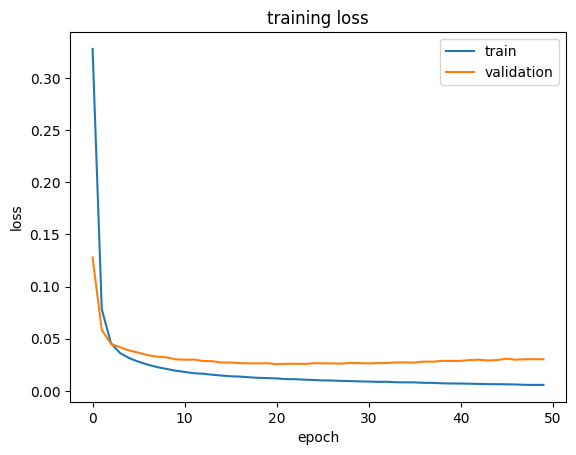

In [23]:
import matplotlib.pyplot as plt

# plot training and validation loss
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="validation")

plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("training loss")
plt.legend()
plt.show()

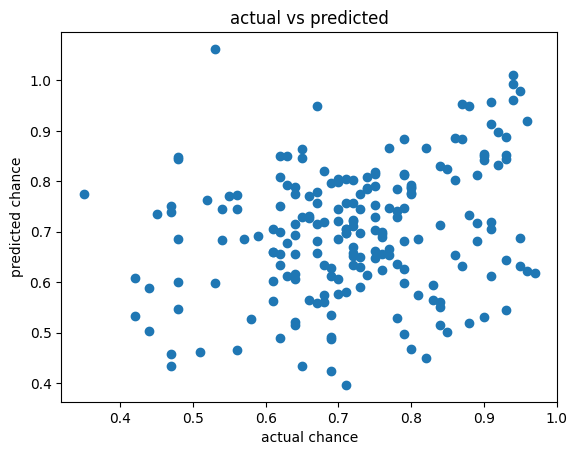

In [24]:
# compare actual and predicted values
plt.scatter(y_test, pred)

plt.xlabel("actual chance")
plt.ylabel("predicted chance")
plt.title("actual vs predicted")
plt.show()

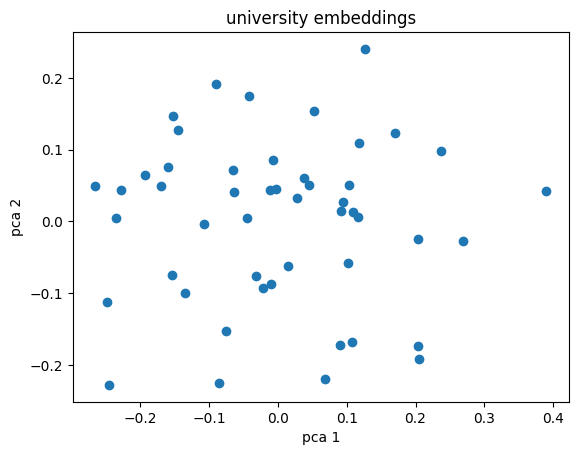

In [25]:
from sklearn.decomposition import PCA

# get university vectors
vec = model.layers[2].get_weights()[0]

# reduce vectors to 2 dimensions
pca = PCA(n_components=2)
v = pca.fit_transform(vec)

plt.scatter(v[:, 0], v[:, 1])

plt.xlabel("pca 1")
plt.ylabel("pca 2")
plt.title("university embeddings")
plt.show()